## Exploratory Data Analysis (EDA) on City Air Quality Index

### Project Objective

The objective of this project is to analyze the Air Quality Index (AQI) data collected from different cities. The analysis aims to identify pollution trends, understand the relationships between pollutants and AQI, compare air quality across cities, and derive meaningful insights to help environmental agencies and policymakers make informed decisions.

The project includes:
- Data Cleaning and Preprocessing
- Feature Engineering (Metric Development)
- Exploratory Data Analysis (EDA)
- Data Visualization using Matplotlib and Seaborn
- Business Question Analysis
- Conclusion and Recommendations

In [1]:
# Importing Libraries that will be used in the Project
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# Reading the CSV File
a=pd.read_csv('/kaggle/input/datasets/sonalsharma98/air-quality-index/city_day.csv')


In [3]:
df=pd.DataFrame(a)

In [6]:
# Displaying the top 10 records 

df.head(10)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [3]:
# Displays Rows and columns
df.shape

(29531, 16)

In [10]:
# Displays information about the data such as non-null values, data types, memory usage , etc.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [12]:
# Displays all the columns

df.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [13]:
# Displys the values within columns
df.values

array([['Ahmedabad', '2015-01-01', nan, ..., 0.0, nan, nan],
       ['Ahmedabad', '2015-01-02', nan, ..., 3.77, nan, nan],
       ['Ahmedabad', '2015-01-03', nan, ..., 2.25, nan, nan],
       ...,
       ['Visakhapatnam', '2020-06-29', 22.91, ..., 0.0, 68.0,
        'Satisfactory'],
       ['Visakhapatnam', '2020-06-30', 16.64, ..., 0.0, 54.0,
        'Satisfactory'],
       ['Visakhapatnam', '2020-07-01', 15.0, ..., nan, 50.0, 'Good']],
      dtype=object)

In [11]:
# Product of rows and columns
df.size

472496

In [8]:
# Data Types
df.dtypes

City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

***Data Cleaning and preprocessing***

In [19]:
# Check Missing Values
df.isna().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

In [32]:
# Calculate Missing Value Percentage
missing_val = df.isnull().sum()/len(df)*100

missing_val.sort_values(ascending=False)

City          0.0
Date          0.0
PM2.5         0.0
PM10          0.0
NO            0.0
NO2           0.0
NOx           0.0
NH3           0.0
CO            0.0
SO2           0.0
O3            0.0
Benzene       0.0
Toluene       0.0
Xylene        0.0
AQI           0.0
AQI_Bucket    0.0
year          0.0
Month         0.0
Day Name      0.0
dtype: float64

In [10]:
fill_values={
    'PM2.5':0,
    'PM10' :0,
    'NO' :0,
    'NO2':0,
    'NOx':0,
    'NH3': 0,
    'CO': 0,
    'SO2': 0,
     'O3': 0,
    'Benzene':0,
    'Toluene': 0,
    'Xylene':0,
    'AQI' :0,
    'AQI_Bucket':0
    
}

In [11]:
# Filling out missing values
df=df.fillna(value=fill_values)

In [13]:
# Check for duplicate records

df.duplicated().sum()

np.int64(0)

In [15]:
df['Date']

0        2015-01-01
1        2015-01-02
2        2015-01-03
3        2015-01-04
4        2015-01-05
            ...    
29526    2020-06-27
29527    2020-06-28
29528    2020-06-29
29529    2020-06-30
29530    2020-07-01
Name: Date, Length: 29531, dtype: object

In [16]:
# Converting datatype 

df['Date']=pd.to_datetime(df['Date'], format="%Y-%m-%d")

In [17]:
# Creating new column 'Year' from date column
df['year']=df['Date'].dt.year


In [21]:
df['year']

0        2015
1        2015
2        2015
3        2015
4        2015
         ... 
29526    2020
29527    2020
29528    2020
29529    2020
29530    2020
Name: year, Length: 29531, dtype: int32

In [29]:
# Creating new column 'Month' from date column

df['Month']=df['Date'].dt.month

In [23]:
df['Month']

0        1
1        1
2        1
3        1
4        1
        ..
29526    6
29527    6
29528    6
29529    6
29530    7
Name: Month, Length: 29531, dtype: int32

In [26]:
# Creating new column 'Day Name' from date column

df['Day Name']=df['Date'].dt.day_name()

In [27]:
df['Day Name']

0         Thursday
1           Friday
2         Saturday
3           Sunday
4           Monday
           ...    
29526     Saturday
29527       Sunday
29528       Monday
29529      Tuesday
29530    Wednesday
Name: Day Name, Length: 29531, dtype: object

***Statistical Summary***

In [46]:
# For all columns
df.describe(include='all')

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,year,Month
count,29531,29531,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531,29531.000000,29531.000000
unique,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN,NaN
top,Ahmedabad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Moderate,NaN,NaN
freq,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8829,NaN,NaN
mean,NaN,2018-05-14 05:40:15.807118080,56.948470,73.565932,15.442981,25.093456,27.730420,15.270502,2.091818,12.635454,29.793840,2.656135,6.331783,1.187464,140.077207,NaN,2017.887914,6.267143
min,NaN,2015-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,2015.000000,1.000000
25%,NaN,2017-04-16 00:00:00,18.390000,0.000000,3.670000,9.100000,6.530000,0.000000,0.400000,4.240000,12.795000,0.000000,0.000000,0.000000,61.000000,NaN,2017.000000,3.000000
50%,NaN,2018-08-05 00:00:00,40.890000,49.000000,8.690000,18.580000,19.700000,7.910000,0.840000,7.930000,27.060000,0.470000,1.090000,0.000000,103.000000,NaN,2018.000000,6.000000
75%,NaN,2019-09-03 00:00:00,72.450000,111.880000,17.570000,34.665000,36.015000,21.755000,1.380000,13.810000,42.730000,2.420000,6.020000,0.430000,179.000000,NaN,2019.000000,9.000000
max,NaN,2020-07-01 00:00:00,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000,NaN,2020.000000,12.000000


In [47]:
# For numerical columns
df.describe()

,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,year,Month
count,29531,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000
mean,2018-05-14 05:40:15.807118080,56.948470,73.565932,15.442981,25.093456,27.730420,15.270502,2.091818,12.635454,29.793840,2.656135,6.331783,1.187464,140.077207,2017.887914,6.267143
min,2015-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2015.000000,1.000000
25%,2017-04-16 00:00:00,18.390000,0.000000,3.670000,9.100000,6.530000,0.000000,0.400000,4.240000,12.795000,0.000000,0.000000,0.000000,61.000000,2017.000000,3.000000
50%,2018-08-05 00:00:00,40.890000,49.000000,8.690000,18.580000,19.700000,7.910000,0.840000,7.930000,27.060000,0.470000,1.090000,0.000000,103.000000,2018.000000,6.000000
75%,2019-09-03 00:00:00,72.450000,111.880000,17.570000,34.665000,36.015000,21.755000,1.380000,13.810000,42.730000,2.420000,6.020000,0.430000,179.000000,2019.000000,9.000000
max,2020-07-01 00:00:00,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000,2020.000000,12.000000
std,NaN,64.250908,91.600663,22.116463,24.764871,31.408837,23.545304,6.740126,17.603451,23.377948,14.284564,17.469547,4.207094,142.666957,1.533783,3.431974


In [48]:
# For Non-numerical columns
df.describe(include='object')

,City,AQI_Bucket
count,29531,29531
unique,26,7
top,Ahmedabad,Moderate
freq,2009,8829


In [50]:
# Mean of Every Numerical Column
df.mean(numeric_only=True)

PM2.5        56.948470
PM10         73.565932
NO           15.442981
NO2          25.093456
NOx          27.730420
NH3          15.270502
CO            2.091818
SO2          12.635454
O3           29.793840
Benzene       2.656135
Toluene       6.331783
Xylene        1.187464
AQI         140.077207
year       2017.887914
Month         6.267143
dtype: float64

In [ ]:
df.median(numeric_only=True)

In [51]:
df.mode(numeric_only=True)

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,year,Month
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019,5


In [52]:
df.max(numeric_only=True)

PM2.5       949.99
PM10       1000.00
NO          390.68
NO2         362.21
NOx         467.63
NH3         352.89
CO          175.81
SO2         193.86
O3          257.73
Benzene     455.03
Toluene     454.85
Xylene      170.37
AQI        2049.00
year       2020.00
Month        12.00
dtype: float64

In [53]:
df.min(numeric_only=True)

PM2.5         0.0
PM10          0.0
NO            0.0
NO2           0.0
NOx           0.0
NH3           0.0
CO            0.0
SO2           0.0
O3            0.0
Benzene       0.0
Toluene       0.0
Xylene        0.0
AQI           0.0
year       2015.0
Month         1.0
dtype: float64

In [54]:
df.std(numeric_only=True)

PM2.5       64.250908
PM10        91.600663
NO          22.116463
NO2         24.764871
NOx         31.408837
NH3         23.545304
CO           6.740126
SO2         17.603451
O3          23.377948
Benzene     14.284564
Toluene     17.469547
Xylene       4.207094
AQI        142.666957
year         1.533783
Month        3.431974
dtype: float64

In [33]:
# Correlation calculation 

correlation = df.corr(numeric_only=True)

correlation

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,year,Month
PM2.5,1.000000,0.368414,0.469201,0.433199,0.382211,0.156542,0.112753,0.164249,0.287599,0.045836,0.167762,0.108134,0.664591,-0.079906,0.042337
PM10,0.368414,1.000000,0.404500,0.330189,0.382156,0.225860,-0.050369,0.148613,0.280985,0.042174,0.108695,0.016662,0.321553,0.198320,-0.022571
NO,0.469201,0.404500,1.000000,0.498892,0.737456,0.170952,0.233470,0.215860,0.120967,0.056948,0.170338,0.100570,0.464506,0.039796,0.023231
NO2,0.433199,0.330189,0.498892,1.000000,0.592442,0.169636,0.369183,0.432338,0.393205,0.064258,0.330047,0.219805,0.577152,0.020988,0.027635
NOx,0.382211,0.382156,0.737456,0.592442,1.000000,0.157394,0.244745,0.218174,0.165240,0.067660,0.208759,0.112985,0.431838,0.030141,0.014906
NH3,0.156542,0.225860,0.170952,0.169636,0.157394,1.000000,-0.073566,-0.057805,0.150708,0.025507,0.019561,-0.052817,0.079939,0.015183,0.004770
CO,0.112753,-0.050369,0.233470,0.369183,0.244745,-0.073566,1.000000,0.478023,0.071831,0.069523,0.290802,0.194980,0.616378,-0.055108,-0.002323
SO2,0.164249,0.148613,0.215860,0.432338,0.218174,-0.057805,0.478023,1.000000,0.241047,0.049392,0.284870,0.266901,0.471956,0.094248,-0.024074
O3,0.287599,0.280985,0.120967,0.393205,0.165240,0.150708,0.071831,0.241047,1.000000,0.050669,0.175583,0.108790,0.317745,0.085895,-0.075231
Benzene,0.045836,0.042174,0.056948,0.064258,0.067660,0.025507,0.069523,0.049392,0.050669,1.000000,0.690560,0.096732,0.065892,0.043354,-0.014966


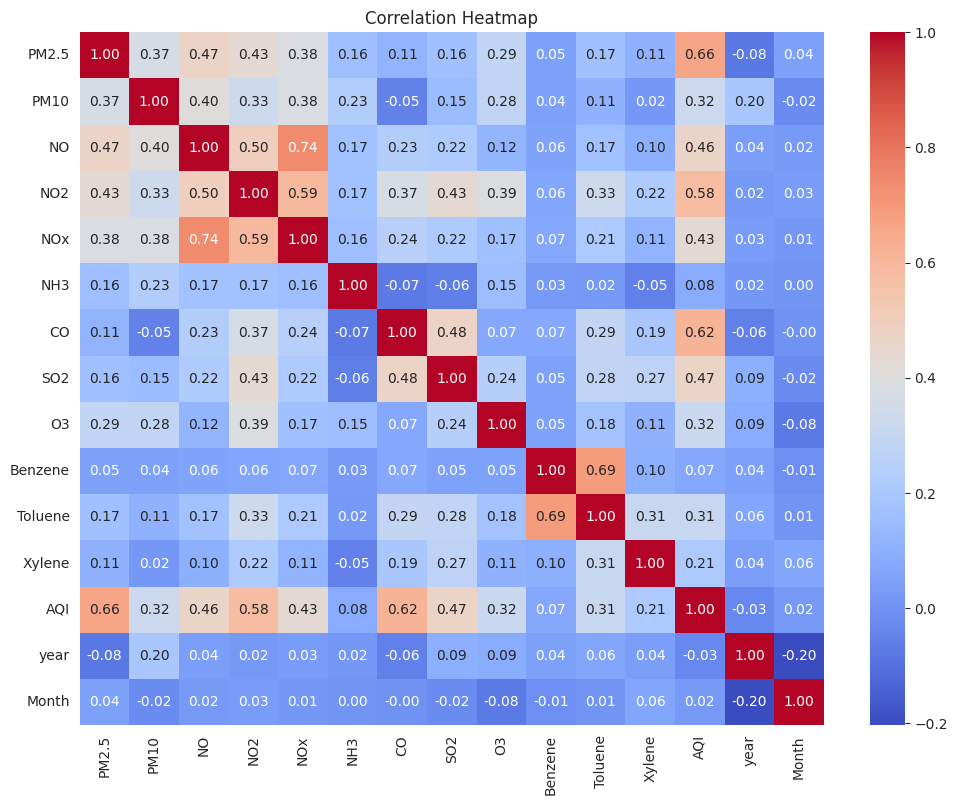

In [34]:
plt.figure(figsize=(12,9))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Business questions and Visualizations

1. Which are the top 10 cities with the highest average Air Quality Index (AQI)?

In [5]:
aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False).reset_index()
       
r=round(aqi.head(10),2)
r

,City,AQI
0,Ahmedabad,452.12
1,Delhi,259.49
2,Patna,240.78
3,Gurugram,225.12
4,Lucknow,217.97
5,Talcher,172.89
6,Jorapokhar,159.25
7,Brajrajnagar,150.28
8,Kolkata,140.57
9,Guwahati,140.11


/tmp/ipykernel_58/2378933495.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


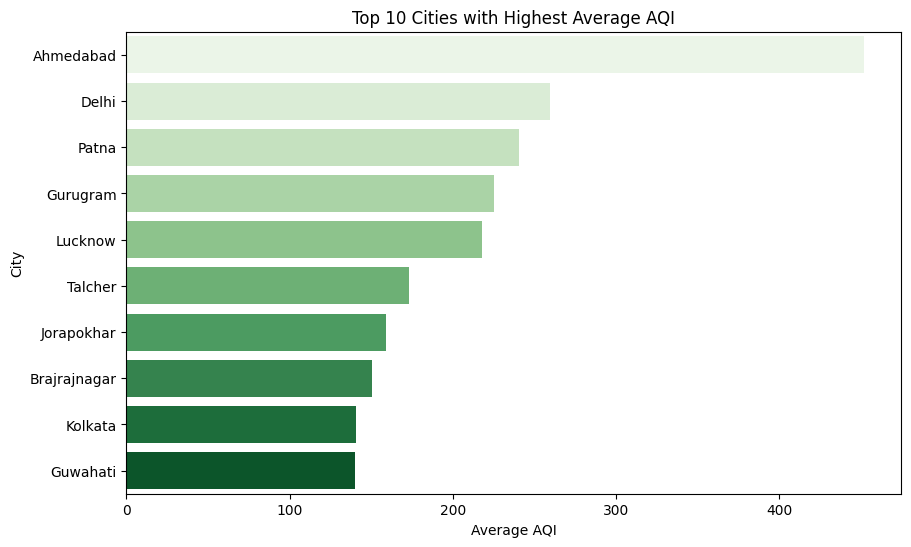

In [6]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=r,
    y='City',
    x='AQI',
    palette='Greens'
)

plt.title("Top 10 Cities with Highest Average AQI")

plt.xlabel("Average AQI")

plt.ylabel("City")

plt.show()

***Ahmedabad has the highest Average AQI***

2. How has the Air Quality Index (AQI) changed over the years?

In [44]:
y_aqi = (df.groupby('year')['AQI'].mean().reset_index())

y_aqi

,year,AQI
0,2015,138.582649
1,2016,145.850201
2,2017,125.161655
3,2018,161.595580
4,2019,148.635509
5,2020,108.023031


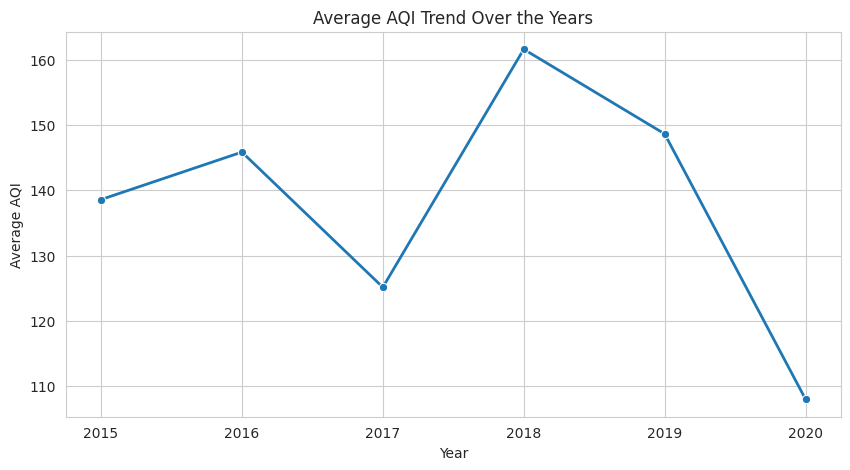

In [46]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=y_aqi,
    x='year',
    y='AQI',
    marker='o',
    linewidth=2
)

plt.title("Average AQI Trend Over the Years")

plt.xlabel("Year")

plt.ylabel("Average AQI")

plt.grid(True)

plt.show()

3. Which city experiences the highest average of NOx pollutants?

In [6]:
df.groupby('City')['NOx'].mean().sort_values(ascending=False)

City
Kochi                 68.412901
Kolkata               63.365695
Delhi                 58.567023
Mumbai                55.038795
Ahmedabad             47.366898
Patna                 45.952471
Guwahati              44.305669
Jaipur                39.637176
Amritsar              35.648294
Talcher               31.895735
Coimbatore            30.887042
Gurugram              29.377311
Visakhapatnam         25.235829
Brajrajnagar          24.542647
Ernakulam             24.287595
Lucknow               22.525300
Bhopal                22.428964
Bengaluru             19.717092
Hyderabad             19.438754
Chennai               17.667942
Amaravati             15.380413
Chandigarh            15.058667
Aizawl                12.610354
Thiruvananthapuram     8.181496
Shillong               1.002202
Jorapokhar                  NaN
Name: NOx, dtype: float64

***Kochi experiences the highest average of NOx pollutants***

4. Which months experience the highest average AQI? Is there any seasonal trend in air pollution?

In [7]:
df['MonthName']=df['Date'].dt.month_name()
df['MonthName']


AttributeError: Can only use .dt accessor with datetimelike values

In [20]:
aqi = (df.groupby('MonthName')['AQI'].mean().reset_index())
aqi

,MonthName,AQI
0,April,143.355120
1,August,113.613176
2,December,227.084980
3,February,202.905197
4,January,231.674918
5,July,111.854575
6,June,120.198379
7,March,164.735281
8,May,135.489579
9,November,241.681302


In [23]:
# For displaying month names in calendar format

cal_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

aqi['MonthName'] = pd.Categorical(
    aqi['MonthName'],categories=cal_order,ordered=True)

aqi = aqi.sort_values('MonthName')
aqi

,MonthName,AQI
4,January,231.674918
3,February,202.905197
7,March,164.735281
0,April,143.355120
8,May,135.489579
6,June,120.198379
5,July,111.854575
1,August,113.613176
11,September,115.191804
10,October,188.613552


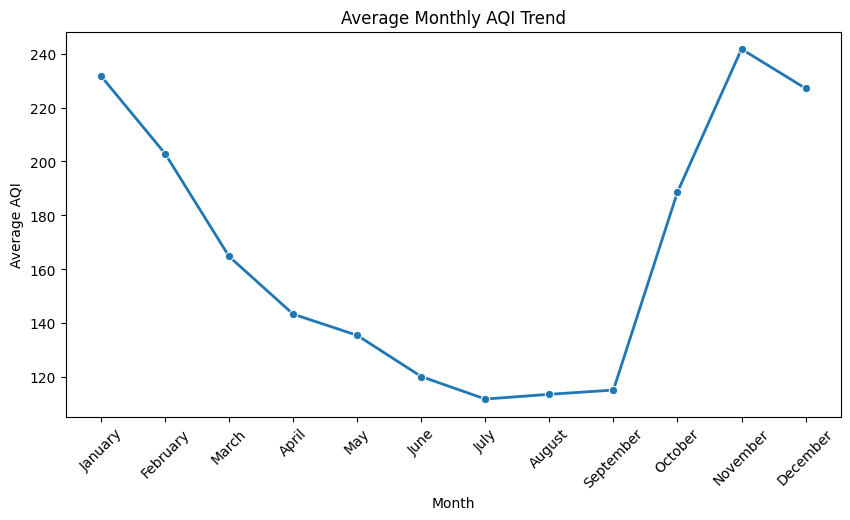

In [25]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=aqi,
    x='MonthName',
    y='AQI',
    marker='o',
    linewidth=2
)

plt.xticks(rotation=45)

plt.title("Average Monthly AQI Trend")

plt.xlabel("Month")

plt.ylabel("Average AQI")

plt.show()

### Summary
This project performed Exploratory Data Analysis (EDA) on the Air Quality Index (AQI) dataset to understand air pollution trends across different cities and identify the major pollutants affecting air quality. The dataset was cleaned by handling missing values, removing duplicates, and converting data into appropriate formats for analysis.

Using Python, Pandas, Matplotlib, and Seaborn, various business questions and visualizations were created to analyze AQI levels, pollutant concentrations, city-wise air quality, and seasonal trends. The analysis identified cities with poor air quality, the most influential pollutants, and changes in pollution levels over time.

Overall, the project demonstrates how data analytics can uncover meaningful insights from environmental data, helping policymakers and environmental agencies monitor pollution, identify high-risk areas, and develop effective strategies to improve air quality and protect public health.